# Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Exercício 1

Aplique um algoritmo de classificação (SVM, por ex), e verifique:

1.   O tempo de execução do algoritmo para realizar o treinamento do
classificador.
2.   A acurácia obtida sobre o conjunto de teste.

In [2]:
# Carregar MNIST
print("Carregando MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

# Divisão padrão: 60 mil para treino e 10 mil para teste
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Formato dos dados:")
print("Treino:", X_train.shape, " | Teste:", X_test.shape)

Carregando MNIST...
Formato dos dados:
Treino: (60000, 784)  | Teste: (10000, 784)


In [3]:
# Padronização dos dados (média 0, desvio padrão 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Padronização concluída.")

Padronização concluída.


In [4]:
svm_clf = LinearSVC(random_state=42, max_iter=5000)

t0 = time.perf_counter()
svm_clf.fit(X_train_scaled, y_train)
t1 = time.perf_counter()

tempo_treino_svm = t1 - t0
y_pred_svm = svm_clf.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Tempo de treino (SVM): {tempo_treino_svm:.2f} segundos")
print(f"Acurácia no conjunto de teste: {acc_svm:.4f}")

Tempo de treino (SVM): 4292.90 segundos
Acurácia no conjunto de teste: 0.9157


## Exercício 2

Utilizando o PCA, reduza a dimensionalidade do conjunto de características
das amostras de modo a preservar 95% de sua variância e aplique o mesmo
algoritmo de classificação utilizado no exercício anterior. Verifique:

1.   O tempo de execução do algoritmo para realizar o treinamento do
classificador.
2.   A acurácia obtida sobre o conjunto de teste.

In [5]:
from sklearn.decomposition import PCA

# Aplicando PCA
pca_95 = PCA(n_components=0.95, svd_solver='full', random_state=42)
t0 = time.perf_counter()
X_train_pca = pca_95.fit_transform(X_train_scaled)
t1 = time.perf_counter()
tempo_pca = t1 - t0

X_test_pca = pca_95.transform(X_test_scaled)
print(f"PCA ajustado. Dimensão original: {X_train.shape[1]}, após PCA: {X_train_pca.shape[1]}")
print(f"Tempo de ajuste do PCA: {tempo_pca:.2f} segundos")

PCA ajustado. Dimensão original: 784, após PCA: 331
Tempo de ajuste do PCA: 9.86 segundos


In [6]:
svm_pca = LinearSVC(random_state=42, max_iter=5000)

t0 = time.perf_counter()
svm_pca.fit(X_train_pca, y_train)
t1 = time.perf_counter()

tempo_treino_pca = t1 - t0
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Tempo de treino (SVM + PCA 95%): {tempo_treino_pca:.2f} segundos")
print(f"Acurácia no conjunto de teste (com PCA): {acc_pca:.4f}")

Tempo de treino (SVM + PCA 95%): 6974.39 segundos
Acurácia no conjunto de teste (com PCA): 0.9188


## Exercício 3

O que você percebeu sobre o tempo de treinamento e a acurácia sobre os
dados de teste antes e depois da aplicação da técnica de redução de
dimensionalidade?

In [7]:
print("=========================================")
print("Comparação entre SVM original e SVM+PCA:")
print("=========================================")
print(f"Tempo de treino (SVM):        {tempo_treino_svm:.2f} s")
print(f"Tempo de treino (SVM + PCA):  {tempo_treino_pca:.2f} s")
print(f"Acurácia (SVM):               {acc_svm:.4f}")
print(f"Acurácia (SVM + PCA 95%):     {acc_pca:.4f}")

print("\nObservação:")
print("- O PCA reduziu o número de atributos, acelerando o treinamento.")
print("- A acurácia pode se manter semelhante ou cair levemente, pois parte da variância é descartada.")

Comparação entre SVM original e SVM+PCA:
Tempo de treino (SVM):        4292.90 s
Tempo de treino (SVM + PCA):  6974.39 s
Acurácia (SVM):               0.9157
Acurácia (SVM + PCA 95%):     0.9188

Observação:
- O PCA reduziu o número de atributos, acelerando o treinamento.
- A acurácia pode se manter semelhante ou cair levemente, pois parte da variância é descartada.


## Exercício 4

Utilize a técnica de reconstrução dos dados compactados e mostre, lado a
lado, o conjunto de dígitos original e o conjunto comprimido com 95%.

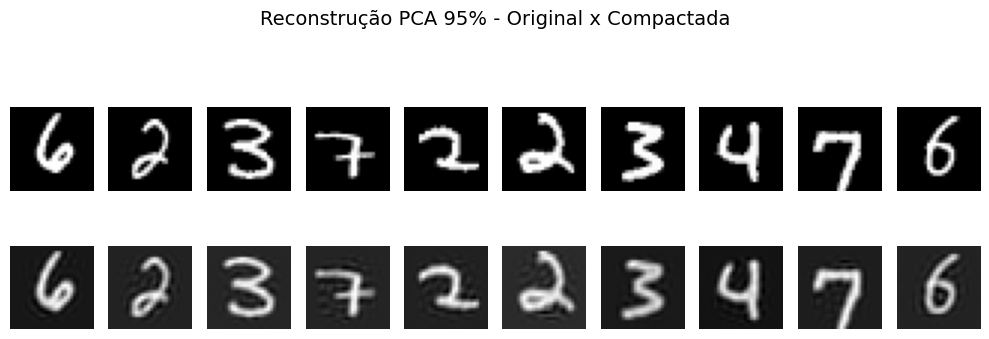

In [8]:
# Selecionar algumas imagens aleatórias
np.random.seed(42)
indices = np.random.choice(len(X_test), size=10, replace=False)

# Reconstituir imagens
X_test_pca_sel = X_test_pca[indices]
X_reconstructed = pca_95.inverse_transform(X_test_pca_sel)
X_reconstructed = scaler.inverse_transform(X_reconstructed)

# Visualização
plt.figure(figsize=(10,4))
for i, idx in enumerate(indices):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Original", fontsize=12)
    # Reconstruída
    plt.subplot(2,10,i+11)
    plt.imshow(X_reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("PCA 95%", fontsize=12)

plt.suptitle("Reconstrução PCA 95% - Original x Compactada", fontsize=14)
plt.tight_layout()
plt.show()

## Exercício 5

Repita a etapa de reconstrução considerando dados comprimidos com o PCA
preservando as seguintes taxas de variação: 30%, 50%, 70%, 90% e 95%.
Exiba as reconstrução das mesmas amostras selecionadas por você no item
anterior.

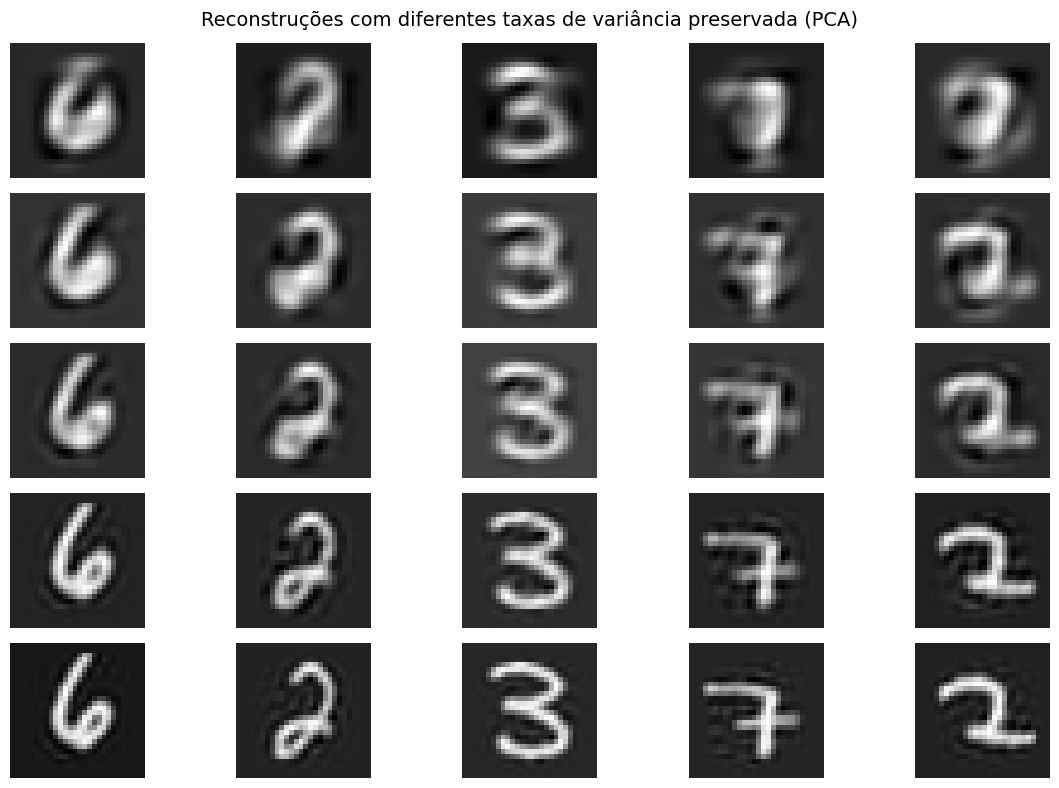

In [9]:
variancias = [0.30, 0.50, 0.70, 0.90, 0.95]

plt.figure(figsize=(12,8))
for i, var in enumerate(variancias):
    pca = PCA(n_components=var, svd_solver='full', random_state=42)
    X_train_pca_var = pca.fit_transform(X_train_scaled)
    X_test_pca_var = pca.transform(X_test_scaled)

    X_test_pca_sel = X_test_pca_var[indices]
    X_rec_var = pca.inverse_transform(X_test_pca_sel)
    X_rec_var = scaler.inverse_transform(X_rec_var)

    for j, idx in enumerate(indices[:5]):  # mostrar 5 dígitos por linha
        plt.subplot(len(variancias), 5, i*5 + j + 1)
        plt.imshow(X_rec_var[j].reshape(28,28), cmap='gray')
        plt.axis('off')
        if j == 0:
            plt.ylabel(f"{int(var*100)}%", fontsize=12)

plt.suptitle("Reconstruções com diferentes taxas de variância preservada (PCA)", fontsize=14)
plt.tight_layout()
plt.show()